In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/neuro-dt1/cleaned_dataset/alz_cleaned/alz_cleaned/ALZHIEMERS_clean/ModerateDemented/T1/aug_7175_8658e2a3-a6d0-4224-a901-1478720f8d49.jpg
/kaggle/input/neuro-dt1/cleaned_dataset/alz_cleaned/alz_cleaned/ALZHIEMERS_clean/ModerateDemented/T1/6fbe016a-060e-4977-adb1-1ed74ba2d365.jpg
/kaggle/input/neuro-dt1/cleaned_dataset/alz_cleaned/alz_cleaned/ALZHIEMERS_clean/ModerateDemented/T1/aab4bc82-3808-468f-bfb5-abb90d5f29e5.jpg
/kaggle/input/neuro-dt1/cleaned_dataset/alz_cleaned/alz_cleaned/ALZHIEMERS_clean/ModerateDemented/T1/aug_7177_83d3bdfd-ad58-482d-82e9-31b6cd6e11ee.jpg
/kaggle/input/neuro-dt1/cleaned_dataset/alz_cleaned/alz_cleaned/ALZHIEMERS_clean/ModerateDemented/T1/aug_8370_85b8f5b2-ca54-489b-98db-f4a74dc115c2.jpg
/kaggle/input/neuro-dt1/cleaned_dataset/alz_cleaned/alz_cleaned/ALZHIEMERS_clean/ModerateDemented/T1/0ce43d4a-df47-4ace-8f9a-53f6771b819f.jpg
/kaggle/input/neuro-dt1/cleaned_dataset/alz_cleaned/alz_cleaned/ALZHIEMERS_clean/ModerateDemented/T1/aug_8841_1173b971-bf

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 194MB/s]



Class counts: [4899.0, 1400.0, 2798.0, 140.0, 22.0, 290.0]
Class weights: [0.003561026183888316, 0.012461047619581223, 0.0062349773943424225, 0.12461047619581223, 0.7929757237434387, 0.06015678122639656]

🚀 Starting training...

Epoch 1/15 | Loss: 0.7054 | Val Acc: 0.8498
Epoch 2/15 | Loss: 0.3204 | Val Acc: 0.8975
Epoch 3/15 | Loss: 0.2027 | Val Acc: 0.9170
Epoch 4/15 | Loss: 0.1244 | Val Acc: 0.9422
Epoch 5/15 | Loss: 0.0946 | Val Acc: 0.9485
Epoch 6/15 | Loss: 0.0644 | Val Acc: 0.9604
Epoch 7/15 | Loss: 0.0444 | Val Acc: 0.9604
Epoch 8/15 | Loss: 0.0384 | Val Acc: 0.9673
Epoch 9/15 | Loss: 0.0278 | Val Acc: 0.9573
Epoch 10/15 | Loss: 0.0412 | Val Acc: 0.9547
Epoch 11/15 | Loss: 0.0456 | Val Acc: 0.9723
Epoch 12/15 | Loss: 0.0394 | Val Acc: 0.9648
Epoch 13/15 | Loss: 0.0175 | Val Acc: 0.9635
Epoch 14/15 | Loss: 0.0349 | Val Acc: 0.9717
Epoch 15/15 | Loss: 0.0126 | Val Acc: 0.9755

🎯 Training complete
🏆 Best validation accuracy: 0.9755
💾 Saved best model to: /kaggle/working/best_mode

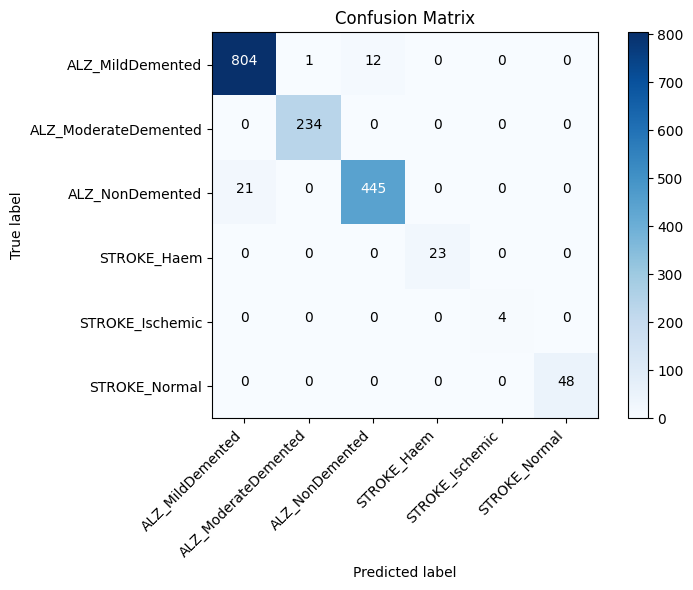


Final Test Accuracy: 97.86%


In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import itertools

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BASE_DIR = "/kaggle/input/neuro-dt1/cleaned_dataset"

alz_path = "/kaggle/input/neuro-dt1/cleaned_dataset/alz_cleaned/alz_cleaned/ALZHIEMERS_clean"
stroke_path = "/kaggle/input/neuro-dt1/cleaned_dataset/cleaned_stroke_dataset/STROKE"

classes = []
image_paths = []
labels = []

# ------------ LOAD ALZHEIMER'S ------------
for subtype in os.listdir(alz_path):
    cls_name = f"ALZ_{subtype}"
    classes.append(cls_name)

    subtype_path = os.path.join(alz_path, subtype)
    for modality in os.listdir(subtype_path):
        mod_path = os.path.join(subtype_path, modality)
        for img in os.listdir(mod_path):
            image_paths.append(os.path.join(mod_path, img))
            labels.append(cls_name)

# ------------ LOAD STROKE ------------
for subtype in os.listdir(stroke_path):
    cls_name = f"STROKE_{subtype}"
    classes.append(cls_name)

    subtype_path = os.path.join(stroke_path, subtype)
    for modality in os.listdir(subtype_path):
        mod_path = os.path.join(subtype_path, modality)
        for img in os.listdir(mod_path):
            image_paths.append(os.path.join(mod_path, img))
            labels.append(cls_name)

classes = sorted(list(set(classes)))
class_to_idx = {c: i for i, c in enumerate(classes)}

# ---------------- DATASET ----------------
class NeuroDataset(Dataset):
    def __init__(self, paths, labels, is_stroke):
        self.paths = paths
        self.labels = labels
        self.is_stroke = is_stroke
        
        self.alz_transform = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
        ])

        self.stroke_transform = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.RandomRotation(12),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        
        label = class_to_idx[self.labels[idx]]

        if self.is_stroke[idx] == 1:
            img = self.stroke_transform(img)
        else:
            img = self.alz_transform(img)

        return img, torch.tensor(label)

# mark stroke samples
is_stroke = [1 if "STROKE" in l else 0 for l in labels]

# ---------------- SPLITS ----------------
X_train, X_temp, y_train, y_temp, s_train, s_temp = train_test_split(
    image_paths, labels, is_stroke, test_size=0.25, random_state=42, stratify=labels
)

X_val, X_test, y_val, y_test, s_val, s_test = train_test_split(
    X_temp, y_temp, s_temp, test_size=0.5, random_state=42, stratify=y_temp
)

train_dataset = NeuroDataset(X_train, y_train, s_train)
val_dataset = NeuroDataset(X_val, y_val, s_val)
test_dataset = NeuroDataset(X_test, y_test, s_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# ---------------- MODEL ----------------
model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(classes))
model = model.to(DEVICE)

# ⭐ CLASS WEIGHTS (computed from training labels)
train_indices = [class_to_idx[l] for l in y_train]
class_counts = np.bincount(train_indices, minlength=len(classes))
class_counts = torch.tensor(class_counts, dtype=torch.float)

# inverse frequency -> rarer classes get higher weight
weights = 1.0 / (class_counts + 1e-6)
weights = weights / weights.sum()

print("\nClass counts:", class_counts.tolist())
print("Class weights:", weights.tolist())

criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE))

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 15
best_val_acc = 0.0
best_state = None

print("\n🚀 Starting training...\n")

# ---------------- TRAIN ----------------
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # ---- VALIDATION ----
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            outputs = model(imgs)
            preds = outputs.argmax(1)
            correct += (preds == lbls).sum().item()
            total += lbls.size(0)

    val_acc = correct / total

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model.state_dict()

# ---------------- SAVE BEST ----------------
BEST_MODEL_PATH = "/kaggle/working/best_model.pth"
torch.save(best_state, BEST_MODEL_PATH)

print(f"\n🎯 Training complete")
print(f"🏆 Best validation accuracy: {best_val_acc:.4f}")
print(f"💾 Saved best model to: {BEST_MODEL_PATH}")

# ---------------- LOAD BEST ----------------
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

# ---------------- TEST ----------------
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(lbls.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45, ha="right")
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

accuracy = (np.array(y_true) == np.array(y_pred)).mean()
print(f"\nFinal Test Accuracy: {accuracy*100:.2f}%")

# ---------------- PREDICT FUNCTION ----------------
def predict_image(path):
    img = Image.open(path).convert("RGB")

    tfm = transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.ToTensor()
    ])

    img = tfm(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(img)
        pred = outputs.argmax(1).item()

    label = classes[pred]

    if label.startswith("ALZ"):
        disease = "Alzheimer's"
        subtype = label.replace("ALZ_", "")
    else:
        disease = "Stroke"
        subtype = label.replace("STROKE_", "")

    print("\nPrediction:")
    print(f"Disease: {disease}")
    print(f"Subtype: {subtype}")

    return disease, subtype


In [2]:
predict_image("/kaggle/input/neuro-dt1/cleaned_dataset/cleaned_stroke_dataset/STROKE/Haem/DWI/Kuppusamy DWI-6.jpg")



Prediction:
Disease: Stroke
Subtype: Haem


('Stroke', 'Haem')

In [3]:
predict_image("/kaggle/input/neuro-dt1/cleaned_dataset/alz_cleaned/alz_cleaned/ALZHIEMERS_clean/ModerateDemented/FLAIR/067ee033-f033-4688-a237-58f0c11b90d9.jpg")



Prediction:
Disease: Alzheimer's
Subtype: ModerateDemented


("Alzheimer's", 'ModerateDemented')

In [6]:
predict_image("/kaggle/input/neuro-dt1/cleaned_dataset/alz_cleaned/alz_cleaned/ALZHIEMERS_clean/MildDemented/T1/000f173f-ebd5-4ef7-b4d4-6cf80cf754b5.jpg")


Prediction:
Disease: Alzheimer's
Subtype: MildDemented


("Alzheimer's", 'MildDemented')

In [7]:
predict_image("/kaggle/input/neuro-dt1/cleaned_dataset/cleaned_stroke_dataset/STROKE/Ischemic/DWI/Gangapushbam DWI-22.jpg")


Prediction:
Disease: Stroke
Subtype: Ischemic


('Stroke', 'Ischemic')

In [8]:
predict_image("/kaggle/input/neuro-dt1/cleaned_dataset/cleaned_stroke_dataset/STROKE/Normal/GRE/Chitra GRE-11.jpg")


Prediction:
Disease: Stroke
Subtype: Normal


('Stroke', 'Normal')

In [11]:
predict_image("/kaggle/input/neuro-dt1/cleaned_dataset/alz_cleaned/alz_cleaned/ALZHIEMERS_clean/NonDemented/T2/065fd9d5-3117-4fae-b2a3-4d3a44a85322.jpg")


Prediction:
Disease: Alzheimer's
Subtype: NonDemented


("Alzheimer's", 'NonDemented')

In [12]:
predict_image("/kaggle/input/neuro-dt1/cleaned_dataset/cleaned_stroke_dataset/STROKE/Ischemic/T2/Ellappan T2-13.jpg")


Prediction:
Disease: Stroke
Subtype: Ischemic


('Stroke', 'Ischemic')